In [69]:
import pandas as pd
import matplotlib.pyplot as plt

In [70]:
path = "./data/migration.csv"

df = pd.read_csv(path, encoding="utf-8")

## Useful dict

In [71]:
countries = {
    "Egipto": "Egypt",
    "Malta": "Malta",
    "Bahamas": "Bahamas",
    "México": "Mexico",
    "República Dominicana": "Dominican Republic",
    "Emiratos Árabes Unidos": "United Arab Emirates",
    "Curazao": "Curacao",
    "Aruba": "Aruba",
    "Panamá": "Panama",
    "Puerto Rico": "Puerto Rico",
}

## Setting up

In [72]:
df["Fecha"] = pd.to_datetime(df["Fecha"])
df["Fecha"] = df["Fecha"].dt.year
total_in = df.groupby("País")["Total_in"].sum().sort_values(ascending=False)
total_out = df.groupby("País")["Total_out"].sum().sort_values(ascending=False) 
net_out = (total_out - total_in).sort_values(ascending=False)
net_out = net_out.drop("Colombia")
net_out_10 = net_out.head(10).sort_values(ascending=True)
net_out_10.index = net_out_10.index.map(countries)

## Chart

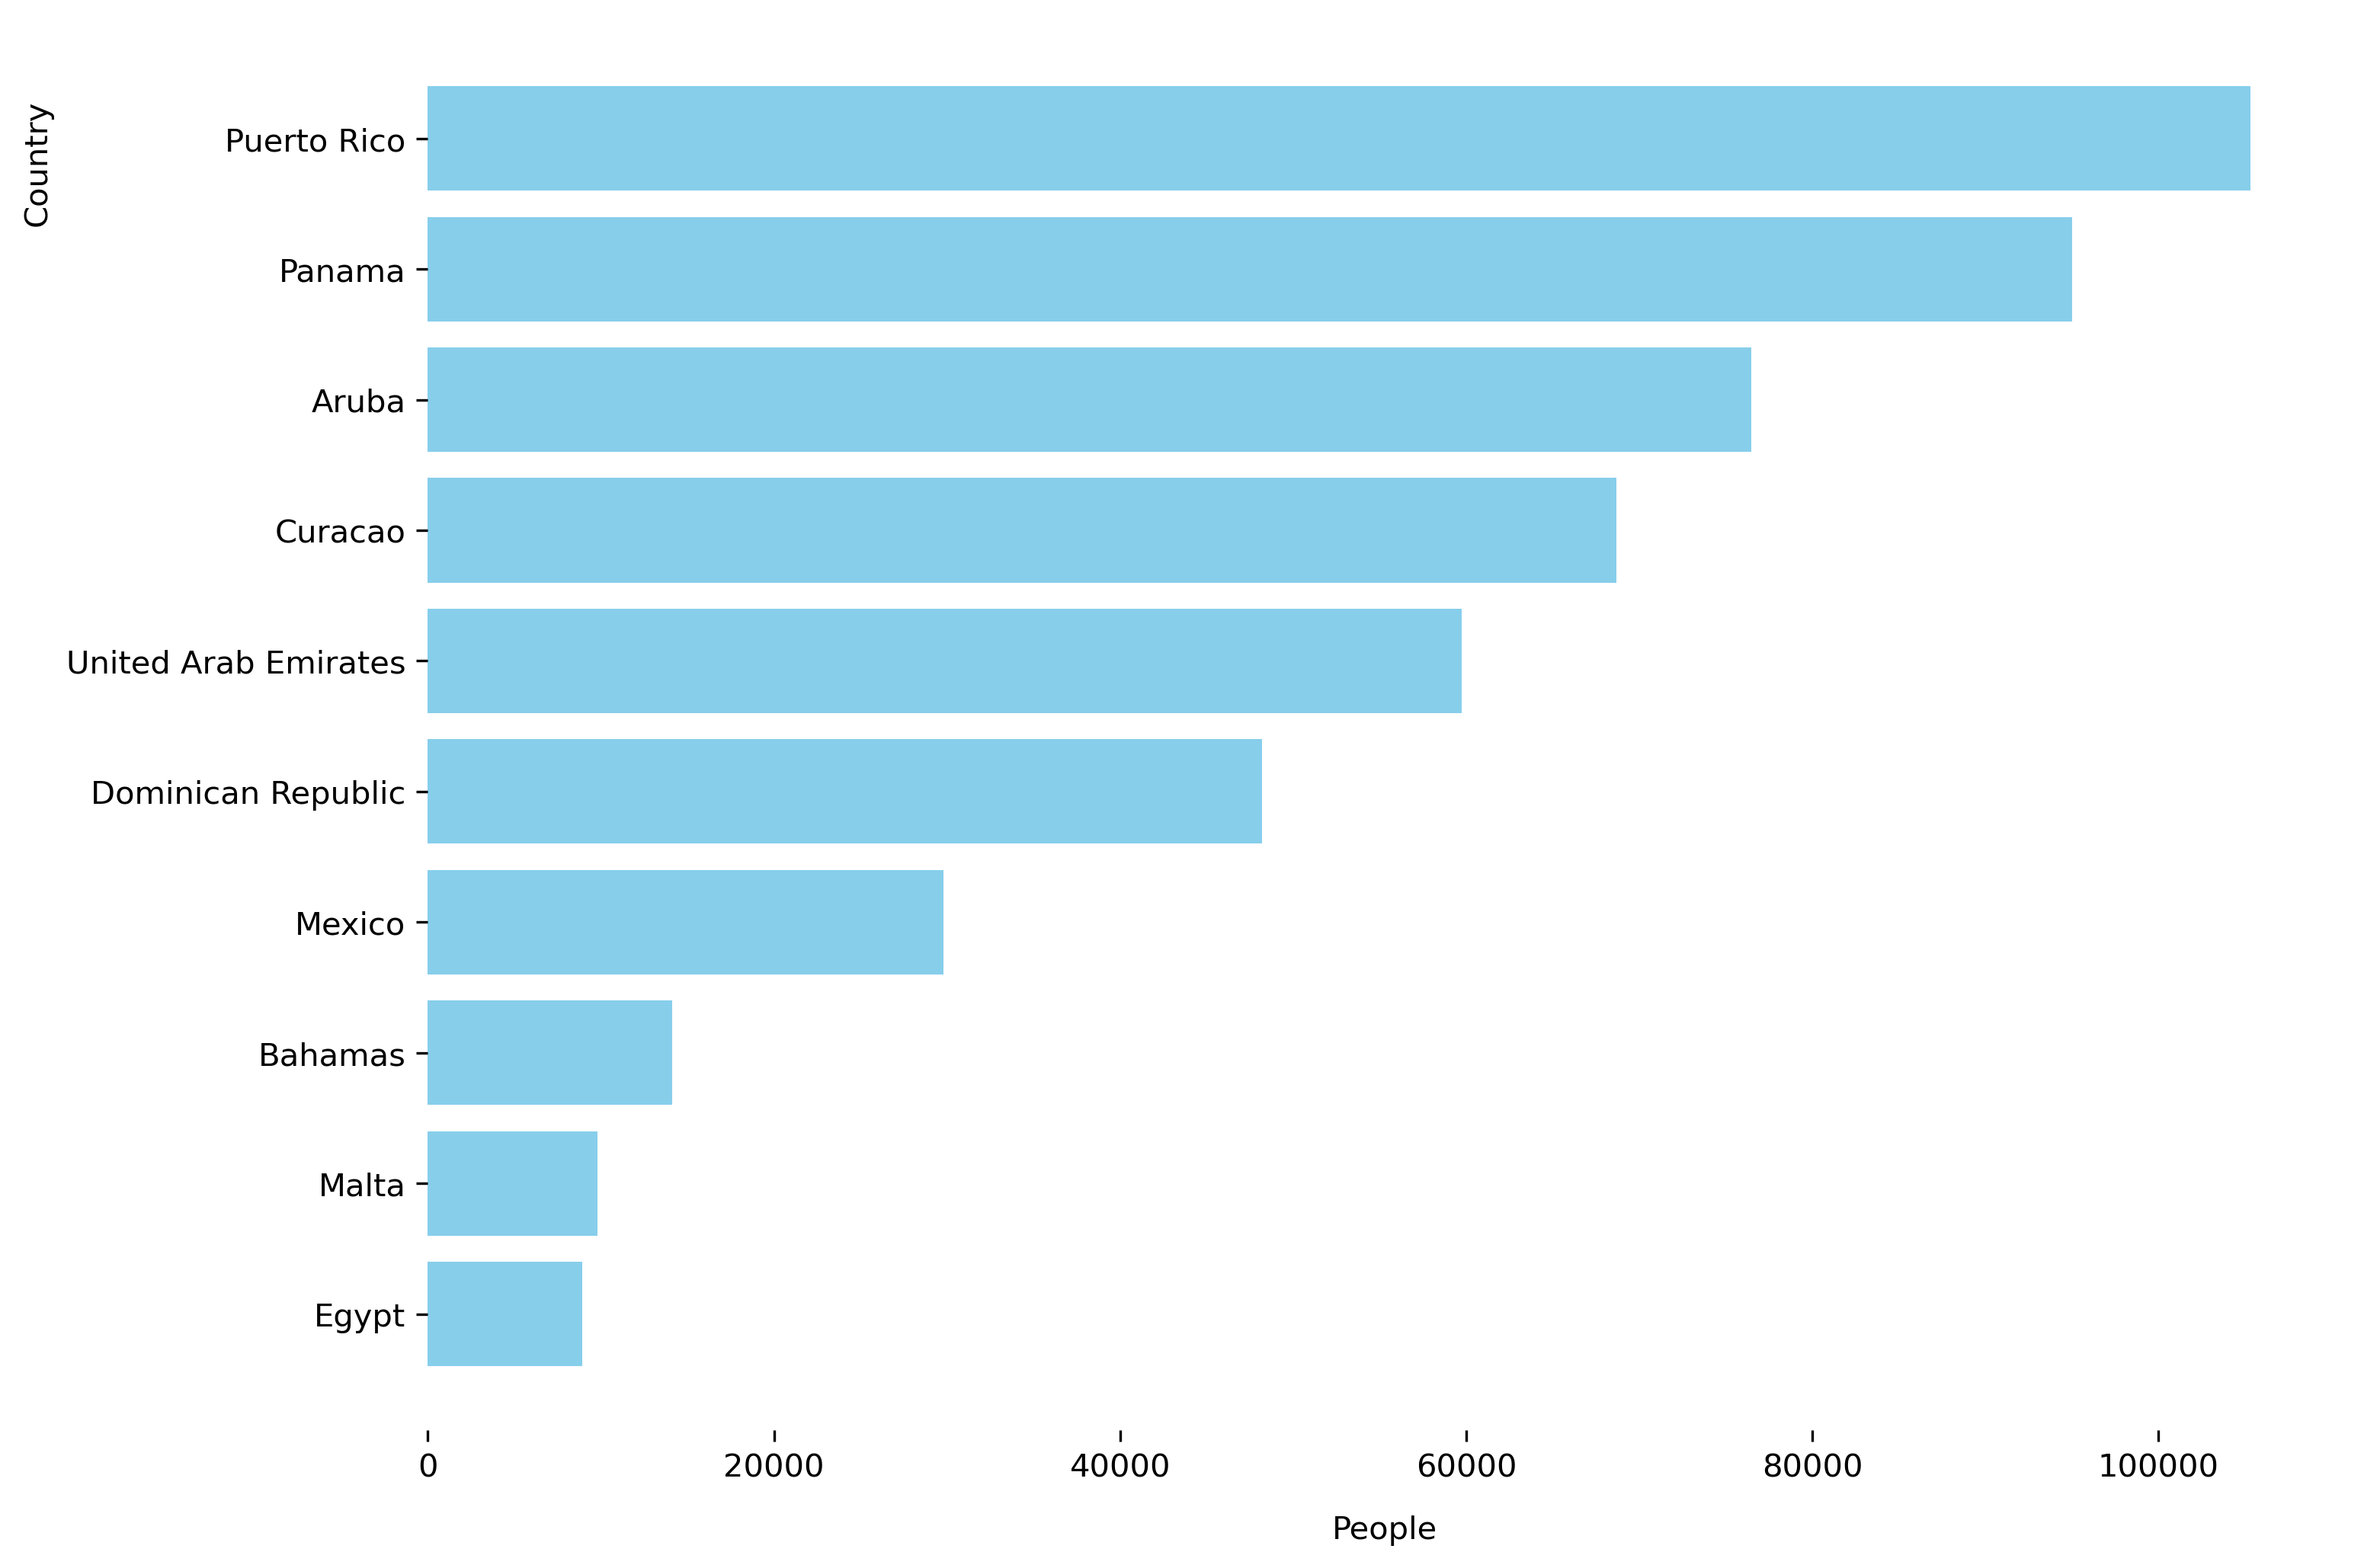

In [75]:
plt.figure(figsize=(10.8, 8), dpi=300)

plt.barh(net_out_10.index, net_out_10.values, color="skyblue")

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)

plt.xlabel("People", labelpad=10, fontsize=10)
plt.ylabel("Country", fontsize=10, y=0.9)

plt.savefig('/home/riosandres/Downloads/a.png', bbox_inches='tight', dpi=300, facecolor='white')